<a href="https://colab.research.google.com/github/anamaciel149/DL_cibernetico/blob/main/TRAB_DL_Ciberseguranca_UNSW_NB15_formato_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDADE DE BRASÍLIA
## Departamento de Engenharia de Produção

# MVP — Deep Learning aplicado à Segurança Cibernética

**Tema:** Detecção de intrusões em redes utilizando Deep Learning  
**Base:** UNSW-NB15  
**Ambiente:** Google Colab  
**Modelo:** Deep Neural Network (DNN / MLP)

## Sumário
1. Apresentação  
2. Objetivo e perguntas  
3. Busca, coleta, modelagem, carga e análise  
4. Ética e licenciamento  
5. Entrega e evidências  
6. Autoavaliação  
7. Checklist

# 1. Apresentação

## 1.1 Problema
Ambientes computacionais produzem grande volume de tráfego de rede, tornando inviável a inspeção manual de todas as conexões. Este MVP investiga o uso de Deep Learning para identificar automaticamente padrões associados a tráfego malicioso.

## 1.2 Hipótese
> Uma rede neural profunda treinada com características de tráfego de rede consegue distinguir registros normais de ataques com desempenho útil, especialmente em recall e F1-score.

## 1.3 Critério de sucesso
Serão analisados:
- Precision
- Recall
- F1-score
- ROC-AUC
- Matriz de confusão

A acurácia será reportada, mas não interpretada isoladamente.

# 2. Objetivo e perguntas

## 2.1 Objetivo geral
Construir um pipeline reproduzível que obtenha a base UNSW-NB15, avalie sua qualidade, prepare os dados, treine uma rede neural profunda e avalie criticamente seu desempenho na detecção de intrusões.

## 2.2 Perguntas
1. Qual é a distribuição entre tráfego normal e ataques?
2. Existem problemas de qualidade capazes de comprometer a modelagem?
3. Uma DNN consegue distinguir tráfego normal de tráfego malicioso?
4. Qual é o desempenho em precision, recall, F1-score e ROC-AUC?
5. Quantos ataques deixam de ser detectados?
6. Quais limitações impedem considerar o MVP pronto para produção?

## 2.3 Plataforma
O notebook foi preparado para Google Colab. A base é baixada do Kaggle e os resultados podem ser persistidos no Google Drive.

# 3. Detalhamento das etapas

## 3.1 Busca pelos dados
A base escolhida é a **UNSW-NB15**, utilizada em estudos de detecção de intrusões. O alvo `label` representa:

- `0`: tráfego normal
- `1`: ataque

A coluna `attack_cat` será retirada das entradas do modelo binário para evitar vazamento de informação.

In [1]:
!pip -q install kagglehub pyarrow

In [2]:
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Execução:", datetime.now().astimezone().isoformat())

TensorFlow: 2.20.0
Execução: 2026-09-28T23:09:27.325017+00:00


## 3.2 Coleta
A coleta é automatizada via KaggleHub. O notebook registra origem, data, formato e volume dos arquivos.

In [3]:
import kagglehub

KAGGLE_DATASET = "mrwellsdavid/unsw-nb15"
coleta_em = datetime.now().astimezone().isoformat()

dataset_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
all_files = sorted([p for p in dataset_path.rglob("*") if p.is_file()])

coleta_info = pd.DataFrame([{
    "arquivo": p.name,
    "formato": p.suffix.lower().replace(".", ""),
    "tamanho_mb": round(p.stat().st_size / (1024**2), 3),
    "origem": f"Kaggle: {KAGGLE_DATASET}",
    "coletado_em": coleta_em
} for p in all_files])

display(coleta_info)

Using Colab cache for faster access to the 'unsw-nb15' dataset.


,arquivo,formato,tamanho_mb,origem,coletado_em
0,NUSW-NB15_features.csv,csv,0.004,Kaggle: mrwellsdavid/unsw-nb15,2026-09-28T23:09:28.313344+00:00
1,UNSW-NB15_1.csv,csv,161.152,Kaggle: mrwellsdavid/unsw-nb15,2026-09-28T23:09:28.313344+00:00
2,UNSW-NB15_2.csv,csv,157.567,Kaggle: mrwellsdavid/unsw-nb15,2026-09-28T23:09:28.313344+00:00
3,UNSW-NB15_3.csv,csv,147.427,Kaggle: mrwellsdavid/unsw-nb15,2026-09-28T23:09:28.313344+00:00
4,UNSW-NB15_4.csv,csv,93.068,Kaggle: mrwellsdavid/unsw-nb15,2026-09-28T23:09:28.313344+00:00
5,UNSW-NB15_LIST_EVENTS.csv,csv,0.004,Kaggle: mrwellsdavid/unsw-nb15,2026-09-28T23:09:28.313344+00:00
6,UNSW_NB15_testing-set.csv,csv,30.797,Kaggle: mrwellsdavid/unsw-nb15,2026-09-28T23:09:28.313344+00:00
7,UNSW_NB15_training-set.csv,csv,14.668,Kaggle: mrwellsdavid/unsw-nb15,2026-09-28T23:09:28.313344+00:00


In [4]:
def choose_file(files, split):
    keys = ["training-set", "training_set", "train"] if split == "train" else ["testing-set", "testing_set", "test"]
    valid = [p for p in files if p.suffix.lower() in {".csv", ".parquet"}]
    found = [p for p in valid if any(k in p.name.lower() for k in keys)]
    if not found:
        raise FileNotFoundError(f"Arquivo de {split} não encontrado.")
    return sorted(found, key=lambda p: (0 if p.suffix.lower()==".parquet" else 1, len(p.name)))[0]

def read_table(p):
    return pd.read_parquet(p) if p.suffix.lower()==".parquet" else pd.read_csv(p)

train_file = choose_file(all_files, "train")
test_file = choose_file(all_files, "test")

train_df = read_table(train_file)
test_df = read_table(test_file)

print("Treino:", train_file.name, train_df.shape)
print("Teste:", test_file.name, test_df.shape)
display(train_df.head())

Treino: UNSW_NB15_training-set.csv (82332, 45)
Teste: UNSW_NB15_testing-set.csv (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


## 3.3 Modelagem e Catálogo de Dados

O MVP utiliza uma estrutura **flat**, em que cada linha representa um registro/fluxo de tráfego.

**Linhagem:** Kaggle → leitura → análise de qualidade → pré-processamento → DNN → métricas.

O catálogo é gerado automaticamente com tipo, domínio observado, nulos, cardinalidade e origem.

In [5]:
def build_catalog(df, origem):
    rows = []
    for col in df.columns:
        s = df[col]
        if pd.api.types.is_numeric_dtype(s):
            tipo = "Numérico"
            dominio = "Sem valores" if s.dropna().empty else f"[{s.min()}, {s.max()}]"
        else:
            tipo = "Categórico/Texto"
            vals = s.dropna().astype(str).value_counts().head(12).index.tolist()
            dominio = ", ".join(vals) + (", ..." if s.nunique(dropna=True) > 12 else "")
        desc = (
            "Rótulo binário: 0=normal; 1=ataque." if col=="label" else
            "Categoria do ataque; removida das entradas do modelo." if col=="attack_cat" else
            "Identificador do registro; removido da modelagem." if col=="id" else
            "Atributo da base UNSW-NB15."
        )
        rows.append({
            "atributo": col,
            "tipo": tipo,
            "descricao": desc,
            "dominio_observado": dominio,
            "nulos": int(s.isna().sum()),
            "cardinalidade": int(s.nunique(dropna=True)),
            "linhagem": origem
        })
    return pd.DataFrame(rows)

catalogo = build_catalog(train_df, f"Kaggle/{KAGGLE_DATASET}/{train_file.name}")
display(catalogo)
catalogo.to_csv("catalogo_dados_unsw_nb15.csv", index=False)

,atributo,tipo,descricao,dominio_observado,nulos,cardinalidade,linhagem
0,id,Numérico,Identificador do registro; removido da modelagem.,"[1, 82332]",0,82332,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...
1,dur,Numérico,Atributo da base UNSW-NB15.,"[0.0, 59.999989]",0,39888,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...
2,proto,Categórico/Texto,Atributo da base UNSW-NB15.,"tcp, udp, unas, arp, ospf, sctp, any, gre, rsv...",0,131,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...
3,service,Categórico/Texto,Atributo da base UNSW-NB15.,"-, dns, http, smtp, ftp, ftp-data, pop3, ssh, ...",0,13,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...
4,state,Categórico/Texto,Atributo da base UNSW-NB15.,"FIN, INT, CON, REQ, ACC, RST, CLO",0,7,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...
5,spkts,Numérico,Atributo da base UNSW-NB15.,"[1, 10646]",0,420,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...
6,dpkts,Numérico,Atributo da base UNSW-NB15.,"[0, 11018]",0,436,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...
7,sbytes,Numérico,Atributo da base UNSW-NB15.,"[24, 14355774]",0,4489,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...
8,dbytes,Numérico,Atributo da base UNSW-NB15.,"[0, 14657531]",0,4034,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...
9,rate,Numérico,Atributo da base UNSW-NB15.,"[0.0, 1000000.003]",0,40616,Kaggle/mrwellsdavid/unsw-nb15/UNSW_NB15_traini...


## 3.4 Carga e persistência

Para manter dados, métricas e modelo após o encerramento da sessão do Colab, o notebook pode montar o Google Drive.

In [6]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PERSIST_DIR = Path("/content/drive/MyDrive/TRAB_DL_CIBERSEGURANCA")
    PERSIST_DIR.mkdir(parents=True, exist_ok=True)
except Exception:
    PERSIST_DIR = Path(".")

coleta_info.to_csv(PERSIST_DIR / "evidencia_coleta.csv", index=False)
catalogo.to_csv(PERSIST_DIR / "catalogo_dados_unsw_nb15.csv", index=False)
train_df.to_parquet(PERSIST_DIR / "UNSW_NB15_training-set.parquet", index=False)
test_df.to_parquet(PERSIST_DIR / "UNSW_NB15_testing-set.parquet", index=False)

print("Persistência:", PERSIST_DIR)

Mounted at /content/drive
Persistência: /content/drive/MyDrive/TRAB_DL_CIBERSEGURANCA


## 3.5 Análise

### 3.5.1 Qualidade dos dados
Serão observadas completude, unicidade, consistência, conformidade e plausibilidade.

In [7]:
train_df = train_df.replace([np.inf, -np.inf], np.nan).copy()
test_df = test_df.replace([np.inf, -np.inf], np.nan).copy()

quality = pd.DataFrame([{
    "atributo": c,
    "nulos": int(train_df[c].isna().sum()),
    "pct_nulos": round(100*train_df[c].isna().mean(),4),
    "unicos": int(train_df[c].nunique(dropna=True)),
    "tipo": str(train_df[c].dtype)
} for c in train_df.columns])

print("Duplicatas completas no treino:", int(train_df.duplicated().sum()))
print("Duplicatas completas no teste:", int(test_df.duplicated().sum()))
display(quality.sort_values(["pct_nulos","atributo"], ascending=[False,True]))

Duplicatas completas no treino: 0
Duplicatas completas no teste: 0


,atributo,nulos,pct_nulos,unicos,tipo
26,ackdat,0,0.0,24020,float64
43,attack_cat,0,0.0,10,object
33,ct_dst_ltm,0,0.0,50,int64
35,ct_dst_sport_ltm,0,0.0,33,int64
36,ct_dst_src_ltm,0,0.0,57,int64
39,ct_flw_http_mthd,0,0.0,8,int64
38,ct_ftp_cmd,0,0.0,3,int64
34,ct_src_dport_ltm,0,0.0,50,int64
40,ct_src_ltm,0,0.0,50,int64
41,ct_srv_dst,0,0.0,57,int64


### 3.5.2 Pergunta 1 — Distribuição das classes

,quantidade,percentual
label,,
0,37000,44.939999
1,45332,55.060001


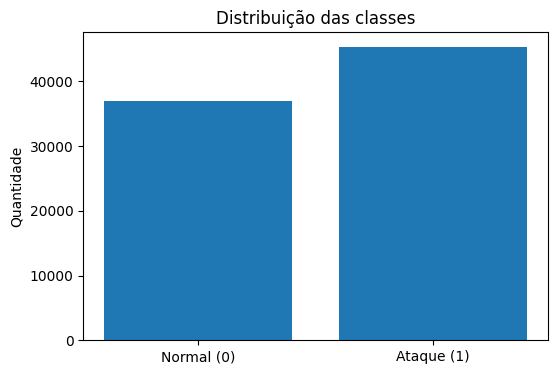

In [8]:
counts = train_df["label"].value_counts().sort_index()
display(
    counts.rename_axis("label").to_frame("quantidade")
    .assign(percentual=lambda x: 100*x["quantidade"]/x["quantidade"].sum())
)

plt.figure(figsize=(6,4))
plt.bar(["Normal (0)", "Ataque (1)"], counts.values)
plt.title("Distribuição das classes")
plt.ylabel("Quantidade")
plt.show()

### 3.5.3 Preparação dos dados

Regras:
- `label` = alvo;
- `attack_cat` removida para evitar leakage;
- `id` removido;
- numéricas: imputação + padronização;
- categóricas: imputação + One-Hot Encoding;
- treino oficial dividido em treino interno e validação;
- teste oficial preservado para avaliação final.

In [9]:
train_df = train_df.dropna(subset=["label"]).copy()
test_df = test_df.dropna(subset=["label"]).copy()

train_df["label"] = train_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

drop_train = [c for c in ["label","attack_cat","id"] if c in train_df.columns]
drop_test = [c for c in ["label","attack_cat","id"] if c in test_df.columns]

X_full = train_df.drop(columns=drop_train)
y_full = train_df["label"]
X_test_raw = test_df.drop(columns=drop_test).reindex(columns=X_full.columns)
y_test = test_df["label"]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=SEED
)

num_cols = X_train_raw.select_dtypes(include=[np.number,"bool"]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32))
])

prep = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

X_train = prep.fit_transform(X_train_raw).astype(np.float32)
X_val = prep.transform(X_val_raw).astype(np.float32)
X_test = prep.transform(X_test_raw).astype(np.float32)

print(X_train.shape, X_val.shape, X_test.shape)

(65865, 190) (16467, 190) (175341, 190)


### 3.5.4 Modelo de Deep Learning

Arquitetura:

**Entrada → Dense 128 → Dense 64 → Dense 32 → Sigmoid**

São utilizados ReLU, Batch Normalization, Dropout, Adam, Binary Cross-Entropy e Early Stopping.

In [10]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c,w in zip(classes,weights)}

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,585 (139.00 KB)

 Trainable params: 35,201 (137.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8485 - auc: 0.9380 - loss: 0.3091 - precision: 0.8818 - recall: 0.8371 - val_accuracy: 0.9125 - val_auc: 0.9794 - val_loss: 0.1969 - val_precision: 0.9684 - val_recall: 0.8694 - learning_rate: 0.0010
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9147 - auc: 0.9777 - loss: 0.1847 - precision: 0.9493 - recall: 0.8928 - val_accuracy: 0.9353 - val_auc: 0.9878 - val_loss: 0.1475 - val_precision: 0.9820 - val_recall: 0.8990 - learning_rate: 0.0010
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9345 - auc: 0.9855 - loss: 0.1505 - precision: 0.9594 - recall: 0.9200 - val_accuracy: 0.9481 - val_auc: 0.9899 - val_loss: 0.1270 - val_precision: 0.9759 - val_recall: 0.9286 - learning_rate: 0.0010
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9440 - auc: 0.9881 - loss: 0.1357 - precision: 0.9646 - recall: 0.9325 - val_accuracy: 0.9484 - val_auc: 0.9897 - val_loss: 0.1244 - v

### 3.5.5 Curvas de treinamento

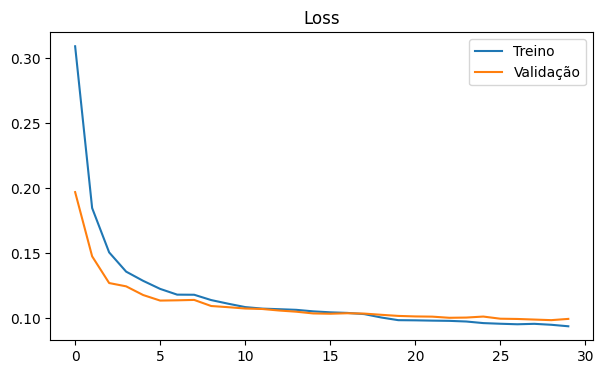

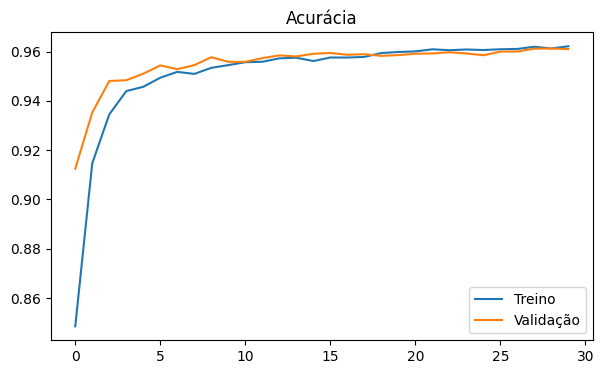

In [12]:
hist = pd.DataFrame(history.history)

plt.figure(figsize=(7,4))
plt.plot(hist["loss"], label="Treino")
plt.plot(hist["val_loss"], label="Validação")
plt.title("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist["accuracy"], label="Treino")
plt.plot(hist["val_accuracy"], label="Validação")
plt.title("Acurácia")
plt.legend()
plt.show()

### 3.5.6 Escolha do limiar

O limiar será escolhido no conjunto de validação maximizando F1-score. O teste permanece independente.

In [13]:
val_prob = model.predict(X_val, verbose=0).ravel()
thresholds = np.arange(0.10,0.91,0.01)
f1s = [f1_score(y_val,(val_prob>=t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(f1s))
best_threshold = float(thresholds[best_idx])

print("Melhor threshold:", round(best_threshold,2))
print("F1 validação:", round(float(f1s[best_idx]),4))

Melhor threshold: 0.47
F1 validação: 0.9649


### 3.5.7 Avaliação final

In [14]:
test_prob = model.predict(X_test, verbose=0).ravel()
test_pred = (test_prob >= best_threshold).astype(int)

metrics = {
    "Acurácia": accuracy_score(y_test,test_pred),
    "Precision": precision_score(y_test,test_pred,zero_division=0),
    "Recall": recall_score(y_test,test_pred,zero_division=0),
    "F1-score": f1_score(y_test,test_pred,zero_division=0),
    "ROC-AUC": roc_auc_score(y_test,test_prob)
}

metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Valor"])
display(metrics_df.style.format("{:.4f}"))

print(classification_report(
    y_test,test_pred,target_names=["Normal","Ataque"],digits=4,zero_division=0
))

,Valor
Acurácia,0.8898
Precision,0.9870
Recall,0.8493
F1-score,0.9130
ROC-AUC,0.9830


              precision    recall  f1-score   support

      Normal     0.7525    0.9761    0.8498     56000
      Ataque     0.9870    0.8493    0.9130    119341

    accuracy                         0.8898    175341
   macro avg     0.8697    0.9127    0.8814    175341
weighted avg     0.9121    0.8898    0.8928    175341



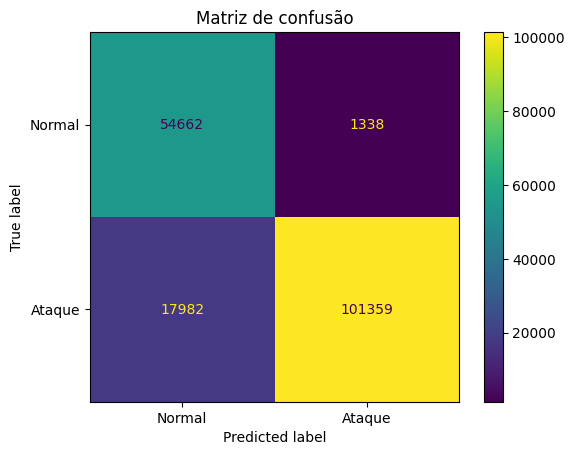

Falsos negativos (ataques não detectados): 17982


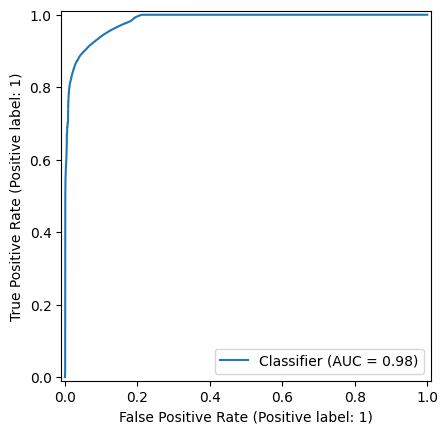

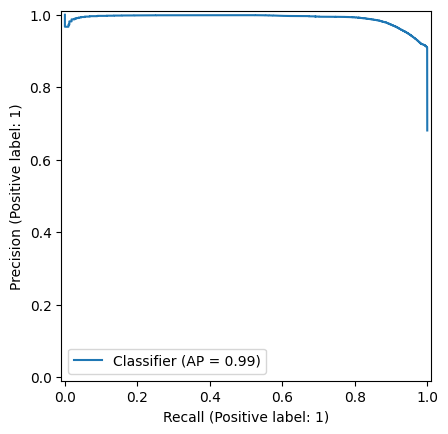

In [15]:
cm = confusion_matrix(y_test,test_pred)
ConfusionMatrixDisplay(cm,display_labels=["Normal","Ataque"]).plot(values_format="d")
plt.title("Matriz de confusão")
plt.show()

tn,fp,fn,tp = cm.ravel()
print("Falsos negativos (ataques não detectados):", fn)

RocCurveDisplay.from_predictions(y_test,test_prob)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test,test_prob)
plt.show()

### 3.5.8 Discussão dos resultados

Após a execução, preencher com os resultados reais:

- distribuição normal × ataque;
- achados de qualidade;
- desempenho da DNN;
- precision, recall, F1 e ROC-AUC;
- quantidade de falsos negativos;
- implicação dos erros.

**Interpretação-chave:** em segurança cibernética, um falso negativo representa um ataque real que não foi detectado.

In [16]:
metrics_out = metrics_df.reset_index().rename(columns={"index":"metrica"})
metrics_out["threshold"] = best_threshold
metrics_out["falsos_negativos"] = fn
metrics_out["falsos_positivos"] = fp

metrics_out.to_csv(PERSIST_DIR / "metricas_modelo.csv", index=False)
hist.to_csv(PERSIST_DIR / "historico_treinamento.csv", index=False)
model.save(PERSIST_DIR / "modelo_dnn_unsw_nb15.keras")

print("Resultados salvos em:", PERSIST_DIR)

Resultados salvos em: /content/drive/MyDrive/TRAB_DL_CIBERSEGURANCA


# 4. Ética, licenciamento e proteção de dados

A versão escolhida no Kaggle informa licença **CC BY-NC-SA 4.0**. A fonte acadêmica original da UNSW permite uso gratuito para pesquisa acadêmica, mediante as citações indicadas pelos autores.

O projeto tem finalidade **defensiva e acadêmica**. Ele identifica padrões de tráfego potencialmente malicioso e não executa ataques.

Em aplicações reais, dados de rede podem envolver informações sensíveis e exigem avaliação adicional de privacidade, segurança e conformidade.

# 5. Entrega e evidências

## Estrutura recomendada
```text
/
├── README.md
├── notebooks/
│   └── trab_dl_ciberseguranca.ipynb
├── catalogo/
│   └── catalogo_dados_unsw_nb15.csv
├── evidencias/
│   ├── evidencia_coleta.csv
│   └── metricas_modelo.csv
├── models/
│   └── modelo_dnn_unsw_nb15.keras
└── LICENSE
```

## Evidências
Registrar screenshots de:
1. download/carregamento;
2. dimensões da base;
3. qualidade dos dados;
4. arquitetura da DNN;
5. curvas de treinamento;
6. métricas finais;
7. matriz de confusão;
8. persistência no Drive.

# 6. Autoavaliação

Preencher ao final:

- Quais perguntas foram respondidas?
- Alguma ficou inconclusiva?
- A hipótese foi sustentada?
- Quais dificuldades apareceram?
- Quais limitações da base condicionaram os resultados?
- O que seria feito de forma diferente?
- O que falta para transformar o MVP em uma solução contínua?

## Trabalhos futuros
- classificação multiclasse por tipo de ataque;
- comparação com outros modelos;
- calibração de threshold por custo;
- dados mais recentes;
- explicabilidade;
- detecção em fluxo contínuo;
- monitoramento de drift.

# 7. Checklist final

- [ ] Objetivo e hipótese claros
- [ ] 3 a 6 perguntas documentadas
- [ ] Origem, licença e data da coleta registradas
- [ ] Catálogo de dados gerado
- [ ] Análise de qualidade feita
- [ ] Transformações documentadas
- [ ] `attack_cat` removida das entradas
- [ ] Treino, validação e teste separados
- [ ] DNN treinada
- [ ] Métricas calculadas
- [ ] Matriz de confusão interpretada
- [ ] Resultados persistidos
- [ ] Limitações discutidas
- [ ] Autoavaliação preenchida
- [ ] Evidências legíveis
- [ ] Notebook executa do início ao fim